In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
titanic = sns.load_dataset("titanic")

In [8]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

labelencoder = LabelEncoder()

titanic["sex"] = labelencoder.fit_transform(titanic["sex"])
titanic["embarked"] = labelencoder.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2
)

In [11]:
# Decision Tree
model = DecisionTreeClassifier(max_depth=4)

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training Accuracy: ", accuracy_score(y_train, y_pred_train)*100, "%")
print("Testing Accuracy: ", accuracy_score(y_test, y_pred_test)*100, "%")

Training Accuracy:  83.98876404494382 %
Testing Accuracy:  79.88826815642457 %


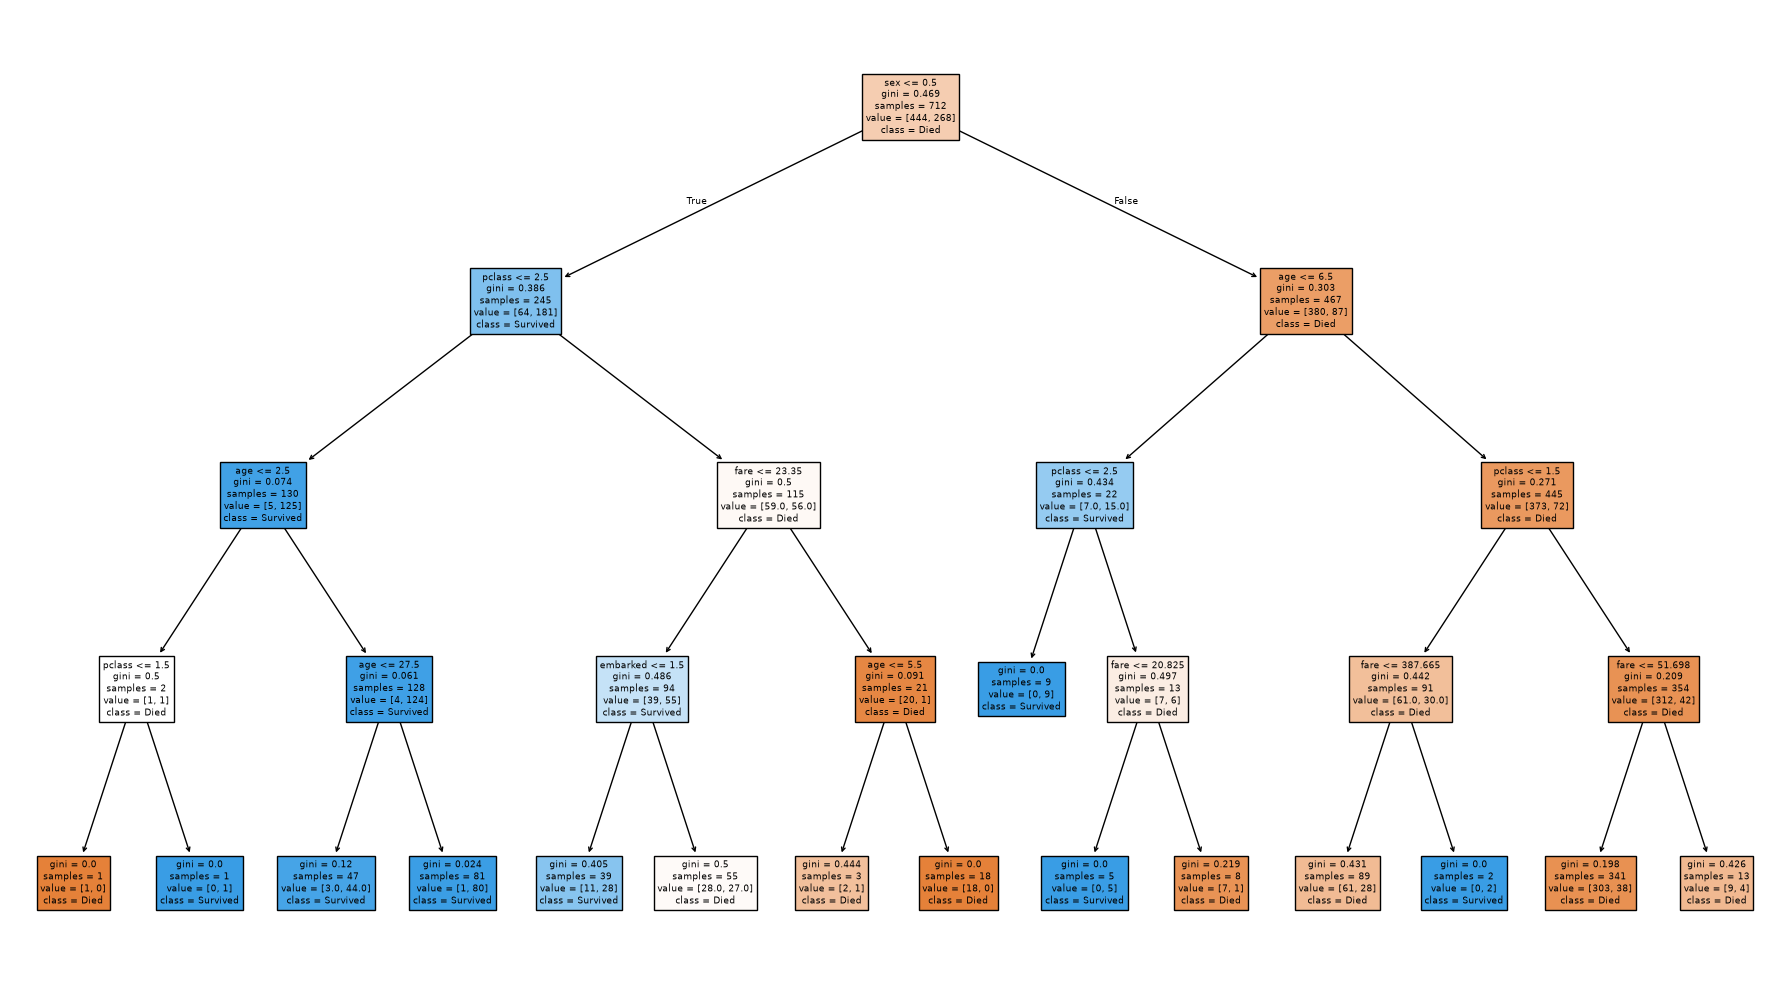

In [12]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)
plt.tight_layout()

In [14]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=501,
    oob_score=True,
    max_depth=4
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("OOB score: ", rf.oob_score_*100, "%")
print("Accuracy", accuracy_score(y_test, y_pred)*100, "%")

OOB score:  82.16292134831461 %
Accuracy 81.56424581005587 %


In [15]:
# Bagging Classifier
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("Accuracy", accuracy_score(y_test, y_pred))

Accuracy 0.8100558659217877


In [17]:
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("Accuracy", accuracy_score(y_test, y_pred))

Accuracy 0.7988826815642458
